# Explore here

In [74]:
from utils import db_connect
engine = db_connect()

# your code here


import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt 
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import MinMaxScaler
from sklearn.feature_selection import chi2, SelectKBest
from sklearn.model_selection import train_test_split


#Imported Necessary Libraries // Librerias necesarias para el proyecto. 

In [75]:
# Load Database / Cargar base de datos.
df = pd.read_csv('/workspaces/Tutorial-Construye-un-modelo-de-regresion-lineal-usando-pandas-y-python/data/raw/demographic_health_data.csv')
total_data = df 
total_data.head()

,fips,TOT_POP,0-9,0-9 y/o % of total pop,19-Oct,10-19 y/o % of total pop,20-29,20-29 y/o % of total pop,30-39,30-39 y/o % of total pop,...,COPD_number,diabetes_prevalence,diabetes_Lower 95% CI,diabetes_Upper 95% CI,diabetes_number,CKD_prevalence,CKD_Lower 95% CI,CKD_Upper 95% CI,CKD_number,Urban_rural_code
0,1001,55601,6787,12.206615,7637,13.735364,6878,12.370281,7089,12.749771,...,3644,12.9,11.9,13.8,5462,3.1,2.9,3.3,1326,3
1,1003,218022,24757,11.355276,26913,12.344167,23579,10.814964,25213,11.564429,...,14692,12.0,11.0,13.1,20520,3.2,3.0,3.5,5479,4
2,1005,24881,2732,10.980266,2960,11.896628,3268,13.134520,3201,12.865239,...,2373,19.7,18.6,20.6,3870,4.5,4.2,4.8,887,6
3,1007,22400,2456,10.964286,2596,11.589286,3029,13.522321,3113,13.897321,...,1789,14.1,13.2,14.9,2511,3.3,3.1,3.6,595,2
4,1009,57840,7095,12.266598,7570,13.087828,6742,11.656293,6884,11.901798,...,4661,13.5,12.6,14.5,6017,3.4,3.2,3.7,1507,2


In [76]:
print(total_data.columns.tolist())
# Print columns to select the target variable for the health study due to socioeconomics issues. / Imprimir las columnas para seleccionar la variable
# objetivo del estudio de salud en cuanto a aspectos socioeconomicos. 

#The chosen variable it is "anycondition_prevalence" (now used as target), because it resumes all possible health problems of the population / La 
# variable elegida es "anycondition_prevalence" (ahora usada como objetivo), porque resume todos los posibles problemas de salud de la población.

['fips', 'TOT_POP', '0-9', '0-9 y/o % of total pop', '19-Oct', '10-19 y/o % of total pop', '20-29', '20-29 y/o % of total pop', '30-39', '30-39 y/o % of total pop', '40-49', '40-49 y/o % of total pop', '50-59', '50-59 y/o % of total pop', '60-69', '60-69 y/o % of total pop', '70-79', '70-79 y/o % of total pop', '80+', '80+ y/o % of total pop', 'White-alone pop', '% White-alone', 'Black-alone pop', '% Black-alone', 'Native American/American Indian-alone pop', '% NA/AI-alone', 'Asian-alone pop', '% Asian-alone', 'Hawaiian/Pacific Islander-alone pop', '% Hawaiian/PI-alone', 'Two or more races pop', '% Two or more races', 'POP_ESTIMATE_2018', 'N_POP_CHG_2018', 'GQ_ESTIMATES_2018', 'R_birth_2018', 'R_death_2018', 'R_NATURAL_INC_2018', 'R_INTERNATIONAL_MIG_2018', 'R_DOMESTIC_MIG_2018', 'R_NET_MIG_2018', 'Less than a high school diploma 2014-18', 'High school diploma only 2014-18', "Some college or associate's degree 2014-18", "Bachelor's degree or higher 2014-18", 'Percent of adults with les

In [77]:
# Database features / Características de la base de datos
print(total_data.shape)
print(total_data.describe())
print(total_data.info())

(3140, 108)
               fips       TOT_POP           0-9  0-9 y/o % of total pop  \
count   3140.000000  3.140000e+03  3.140000e+03             3140.000000   
mean   30401.640764  1.041894e+05  1.274030e+04               11.871051   
std    15150.559265  3.335834e+05  4.180730e+04                2.124081   
min     1001.000000  8.800000e+01  0.000000e+00                0.000000   
25%    18180.500000  1.096325e+04  1.280500e+03               10.594639   
50%    29178.000000  2.580050e+04  3.057000e+03               11.802727   
75%    45081.500000  6.791300e+04  8.097000e+03               12.951840   
max    56045.000000  1.010552e+07  1.208253e+06               25.460677   

             19-Oct  10-19 y/o % of total pop         20-29  \
count  3.140000e+03               3140.000000  3.140000e+03   
mean   1.336798e+04                 12.694609  1.446933e+04   
std    4.228439e+04                  1.815044  4.957773e+04   
min    0.000000e+00                  0.000000  0.000000e+00 

In [78]:
#Eliminate duplicates / Eliminar duplicados. 
total_data[total_data.duplicated(keep=False)]
total_data = total_data.drop_duplicates()
total_data.shape

(3140, 108)

In [79]:
#Check for null values / Verificar valores nulos.
total_data.isnull().sum()

fips                      0
TOT_POP                   0
0-9                       0
0-9 y/o % of total pop    0
19-Oct                    0
                         ..
CKD_prevalence            0
CKD_Lower 95% CI          0
CKD_Upper 95% CI          0
CKD_number                0
Urban_rural_code          0
Length: 108, dtype: int64

In [80]:
#Determinate irrelevant features / Determinar características irrelevantes.
# As we chose "anycondition_prevalence" as target variable, we will eliminate the features and variables linked to any ohter case. 
# Focusing on the socioconomis aspects. Also duplicates of information stored in different columns and ways. /
# Como elegimos "anycondition_prevalence" como variable objetivo, eliminaremos las características y variables vinculadas a cualquier otro caso.
# Enfocándonos en los aspectos socioconomicos. También duplicados de información almacenada en diferentes columnas y formas.

total_data = total_data.drop([ 'fips', 'STATE_FIPS', 'CNTY_FIPS'], axis=1) 

# No predictive features / Características no predictivas.

total_data = total_data.drop([
    '0-9', '19-Oct', '20-29', '30-39', '40-49', '50-59', '60-69', '70-79', '80+',
    'White-alone pop', 'Black-alone pop',
    'Native American/American Indian-alone pop',
    'Asian-alone pop', 'Hawaiian/Pacific Islander-alone pop',
    'Two or more races pop',
    'Less than a high school diploma 2014-18',
    'High school diploma only 2014-18',
    "Some college or associate's degree 2014-18",
    "Bachelor's degree or higher 2014-18",
    'POVALL_2018',
    'Civilian_labor_force_2018', 'Employed_2018', 'Unemployed_2018',
    'Population Aged 60+', 'Total Population', 'POP_ESTIMATE_2018',], axis=1) 

# % version replaced features / Características reemplazadas por porcentajes.

total_data = total_data.drop([
    'Total Active Patient Care Physicians per 100000 Population 2018 (AAMC)',
    'Active Patient Care Primary Care Physicians per 100000 Population 2018 (AAMC)',
    'Active General Surgeons per 100000 Population 2018 (AAMC)',
    'Active Patient Care General Surgeons per 100000 Population 2018 (AAMC)',
    'MEDHHINC_2018',          
    'PCTPOV017_2018',          
    'PCTPOV517_2018',          
], axis=1)

#Almos perfect duplicates / Casi duplicados.

total_data = total_data.drop([
    'R_NATURAL_INC_2018',                    # = R_birth - R_death
    'R_NET_MIG_2018',                        # = R_DOM + R_INTL
    'N_POP_CHG_2018',
    'GQ_ESTIMATES_2018',
    'CI90LBINC_2018', 'CI90UBINC_2018',      # intervalos de confianza del ingreso
    'Med_HH_Income_Percent_of_State_Total_2018',
    'county_pop2018_18 and older',
], axis=1)

# Derived by another variables or redundant metrics./ Metricas derivadas de otras variables o redundantes.

total_data = total_data.drop([
    'R_birth_2018',
    'R_DOMESTIC_MIG_2018',
    'R_INTERNATIONAL_MIG_2018',
], axis=1)

# Irrelevant for the target variable / Irrelevantes para la variable objetivo.

total_data = total_data.drop([
    'R_death_2018',
    'anycondition_Lower 95% CI', 'anycondition_Upper 95% CI', 'anycondition_number',
    'Obesity_prevalence', 'Obesity_Lower 95% CI', 'Obesity_Upper 95% CI', 'Obesity_number',
    'Heart disease_prevalence', 'Heart disease_Lower 95% CI',
    'Heart disease_Upper 95% CI', 'Heart disease_number',
    'COPD_prevalence', 'COPD_Lower 95% CI', 'COPD_Upper 95% CI', 'COPD_number',
    'diabetes_prevalence', 'diabetes_Lower 95% CI',
    'diabetes_Upper 95% CI', 'diabetes_number',
    'CKD_prevalence', 'CKD_Lower 95% CI', 'CKD_Upper 95% CI', 'CKD_number',
], axis=1)

# Cronic conditions correlated to the target variable, but not useful for the model. / 
# Condiciones crónicas correlacionadas con la variable objetivo, pero no útiles para el modelo.

total_data.info()
print(f"\nDimensiones: {total_data.shape}")   
print(total_data.head())





<class 'pandas.DataFrame'>
RangeIndex: 3140 entries, 0 to 3139
Data columns (total 37 columns):
 #   Column                                                                   Non-Null Count  Dtype  
---  ------                                                                   --------------  -----  
 0   TOT_POP                                                                  3140 non-null   int64  
 1   0-9 y/o % of total pop                                                   3140 non-null   float64
 2   10-19 y/o % of total pop                                                 3140 non-null   float64
 3   20-29 y/o % of total pop                                                 3140 non-null   float64
 4   30-39 y/o % of total pop                                                 3140 non-null   float64
 5   40-49 y/o % of total pop                                                 3140 non-null   float64
 6   50-59 y/o % of total pop                                                 3140 non-n

#### Analysis on categorical variables / Analisis en variables categoricas

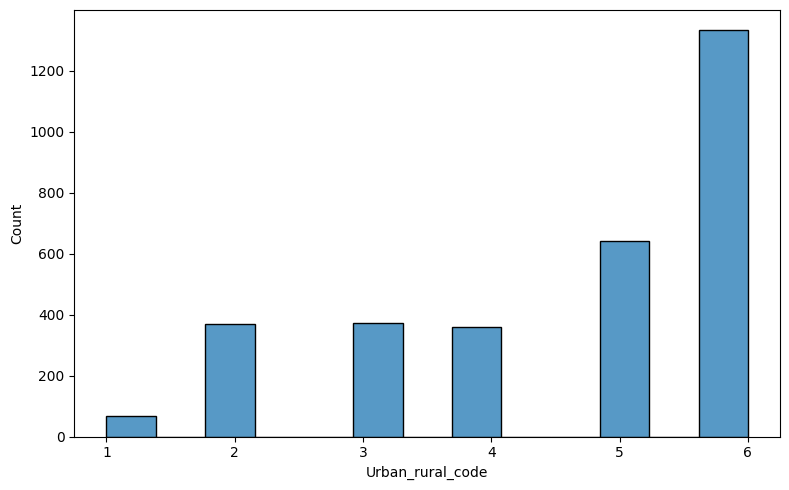

In [81]:
fig, axis = plt.subplots(1, 1, figsize=(8, 5))

# Urban-rural classification is the main categorical variable / La clasificación urbano-rural es la variable categórica principal
sns.histplot(ax = axis, data = total_data, x = "Urban_rural_code")

# Adjust layout / Ajustar el diseño
plt.tight_layout()

# Show the plot / Mostrar el gráfico
plt.show()

#### Analysis on numeric variables / Analisis en variables numericas

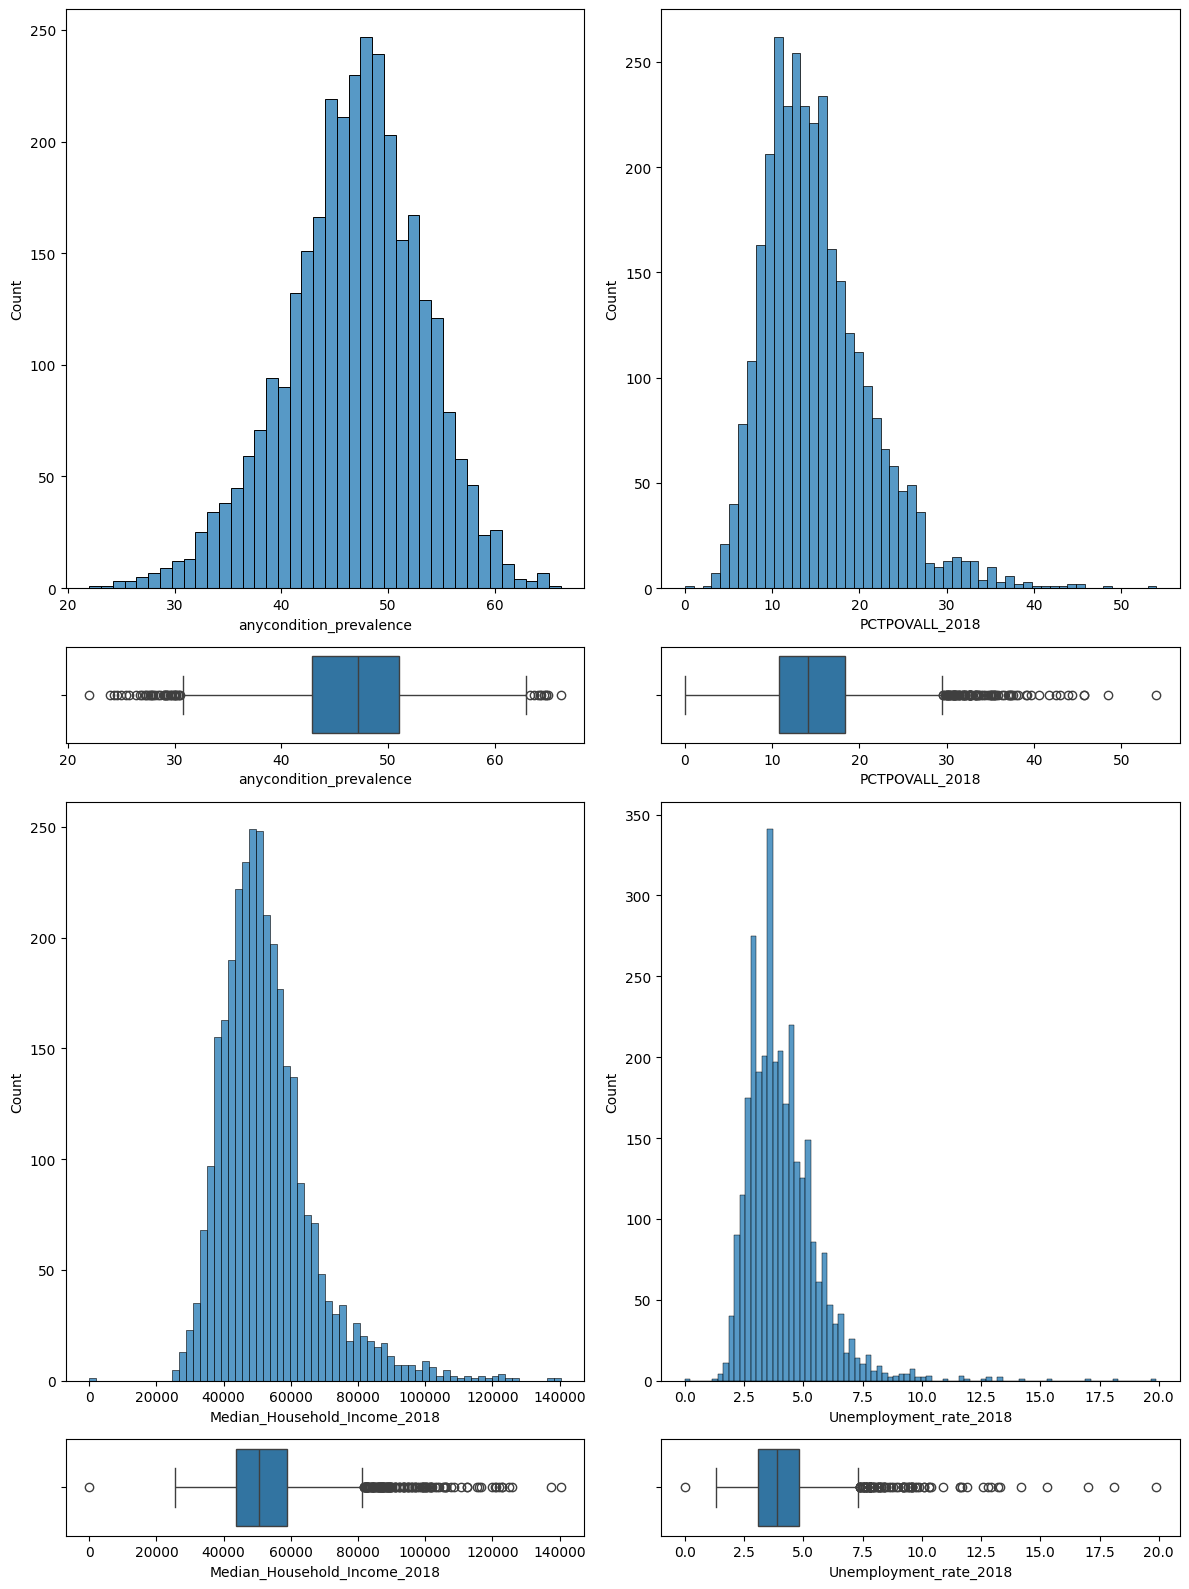

In [82]:
fig, axis = plt.subplots(4, 2, figsize = (12, 16), gridspec_kw = {"height_ratios": [6, 1, 6, 1]})

sns.histplot(ax = axis[0, 0], data = total_data, x = "anycondition_prevalence")
sns.boxplot(ax = axis[1, 0],  data = total_data, x = "anycondition_prevalence")

sns.histplot(ax = axis[0, 1], data = total_data, x = "PCTPOVALL_2018")
sns.boxplot(ax = axis[1, 1],  data = total_data, x = "PCTPOVALL_2018")

sns.histplot(ax = axis[2, 0], data = total_data, x = "Median_Household_Income_2018")
sns.boxplot(ax = axis[3, 0],  data = total_data, x = "Median_Household_Income_2018")

sns.histplot(ax = axis[2, 1], data = total_data, x = "Unemployment_rate_2018")
sns.boxplot(ax = axis[3, 1],  data = total_data, x = "Unemployment_rate_2018")

# Adjust layout / Ajustar el diseño
plt.tight_layout()

# Show the plot / Mostrar el gráfico
plt.show()

#### Numerical-numerical analysis / Analisis numerico-numerico

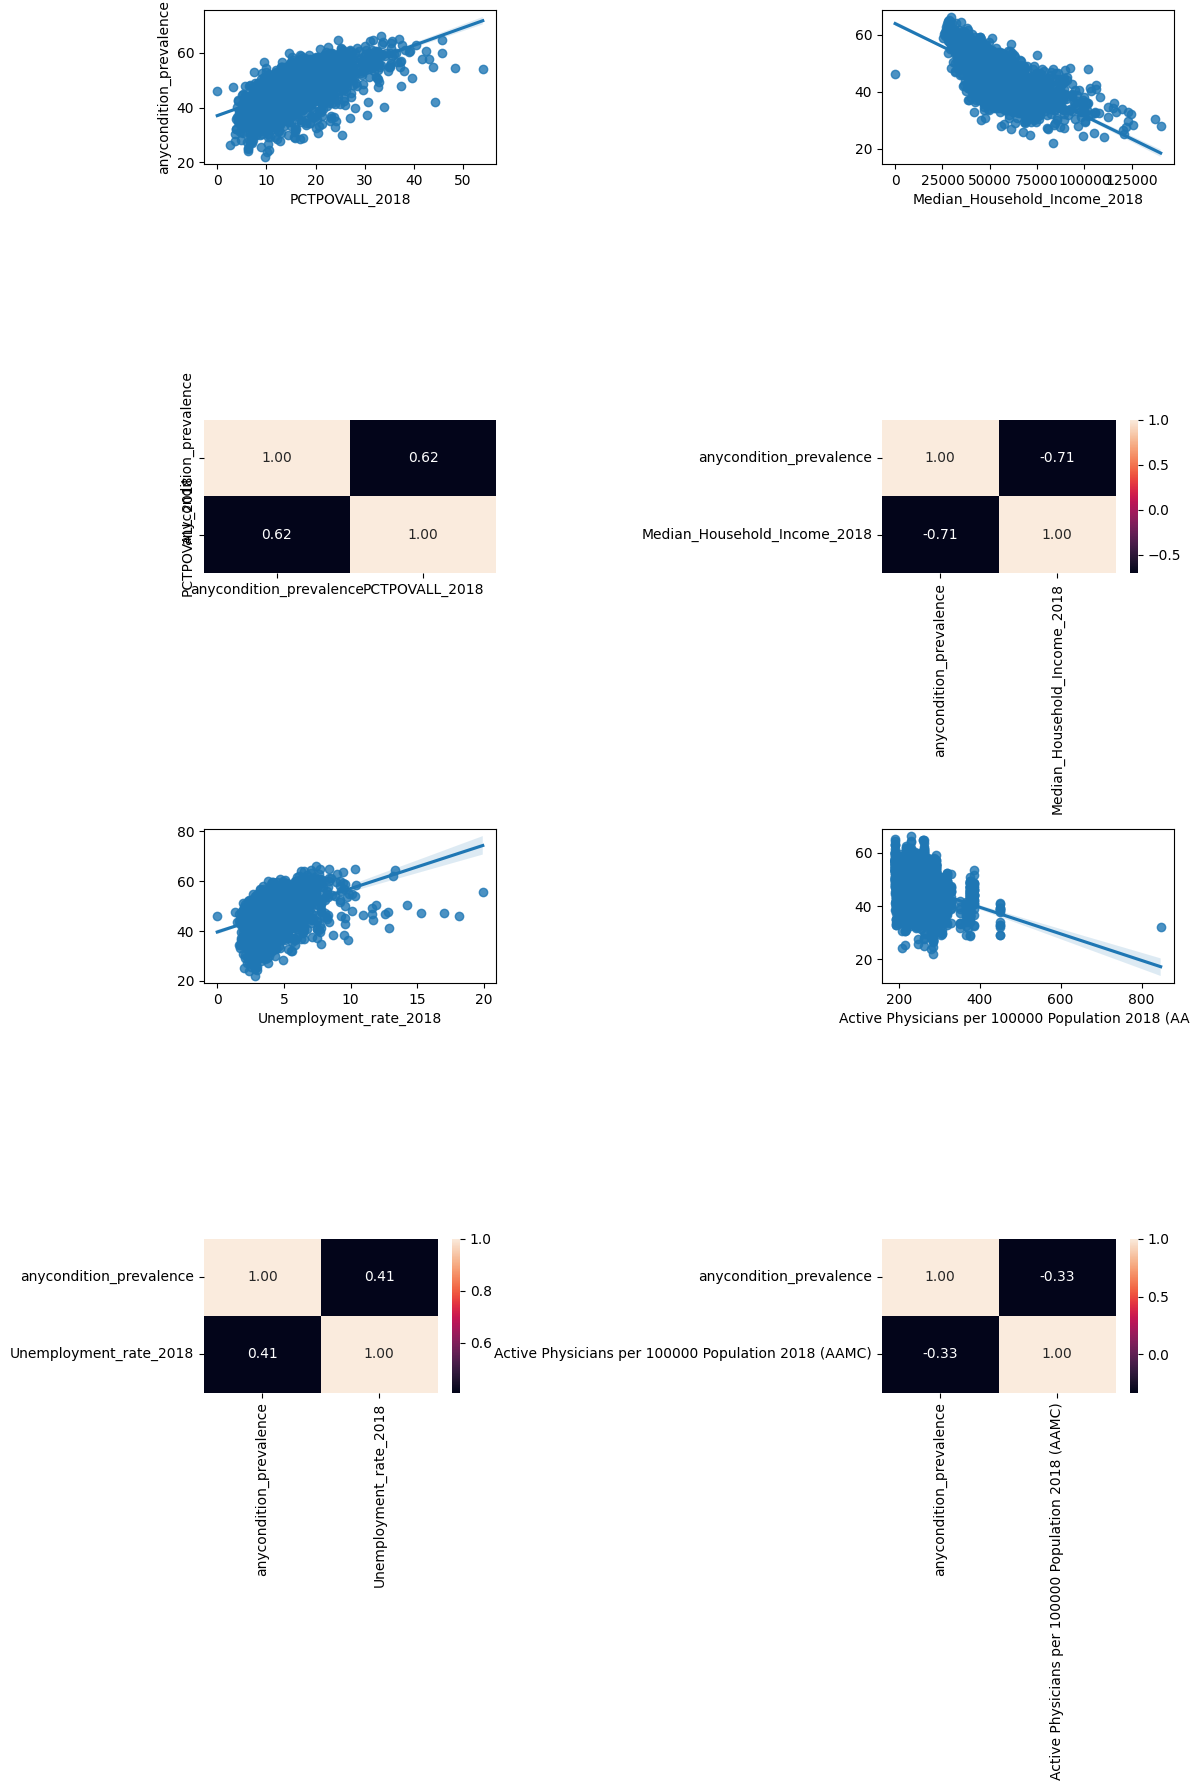

In [83]:
# Numerical - Numerical Analysis / Análisis numérico - numérico

# Create subplot canvas / Crear lienzo de subgráficos
fig, axis = plt.subplots(4, 2, figsize = (12, 18))

# Create Plots / Crear gráficos
sns.regplot(ax = axis[0, 0], data = total_data, x = "PCTPOVALL_2018", y = "anycondition_prevalence")
sns.heatmap(total_data[["anycondition_prevalence", "PCTPOVALL_2018"]].corr(), annot = True, fmt = ".2f", ax = axis[1, 0], cbar = False)

sns.regplot(ax = axis[0, 1], data = total_data, x = "Median_Household_Income_2018", y = "anycondition_prevalence").set(ylabel = None)
sns.heatmap(total_data[["anycondition_prevalence", "Median_Household_Income_2018"]].corr(), annot = True, fmt = ".2f", ax = axis[1, 1])

sns.regplot(ax = axis[2, 0], data = total_data, x = "Unemployment_rate_2018", y = "anycondition_prevalence").set(ylabel = None)
sns.heatmap(total_data[["anycondition_prevalence", "Unemployment_rate_2018"]].corr(), annot = True, fmt = ".2f", ax = axis[3, 0]).set(ylabel = None)

sns.regplot(ax = axis[2, 1], data = total_data, x = "Active Physicians per 100000 Population 2018 (AAMC)", y = "anycondition_prevalence").set(ylabel = None)
sns.heatmap(total_data[["anycondition_prevalence", "Active Physicians per 100000 Population 2018 (AAMC)"]].corr(), annot = True, fmt = ".2f", ax = axis[3, 1]).set(ylabel = None)

# Adjust layout / Ajustar el diseño
plt.tight_layout()

# Show the plot / Mostrar el gráfico
plt.show()

#### Categorical-categorical analysis / Analisis categorico-categorico

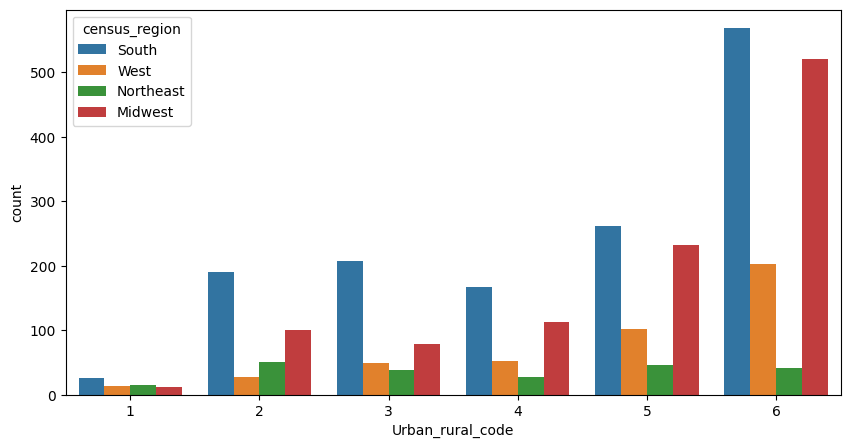

In [84]:
# Map states to US Census regions / Mapear estados a regiones censales de EE.UU.
census_region_map = {
    'Alabama': 'South',     'Alaska': 'West',         'Arizona': 'West',         'Arkansas': 'South',
    'California': 'West',   'Colorado': 'West',        'Connecticut': 'Northeast', 'Delaware': 'South',
    'Florida': 'South',     'Georgia': 'South',        'Hawaii': 'West',           'Idaho': 'West',
    'Illinois': 'Midwest',  'Indiana': 'Midwest',      'Iowa': 'Midwest',          'Kansas': 'Midwest',
    'Kentucky': 'South',    'Louisiana': 'South',      'Maine': 'Northeast',       'Maryland': 'South',
    'Massachusetts': 'Northeast', 'Michigan': 'Midwest', 'Minnesota': 'Midwest',  'Mississippi': 'South',
    'Missouri': 'Midwest',  'Montana': 'West',         'Nebraska': 'Midwest',      'Nevada': 'West',
    'New Hampshire': 'Northeast', 'New Jersey': 'Northeast', 'New Mexico': 'West', 'New York': 'Northeast',
    'North Carolina': 'South', 'North Dakota': 'Midwest', 'Ohio': 'Midwest',      'Oklahoma': 'South',
    'Oregon': 'West',       'Pennsylvania': 'Northeast', 'Rhode Island': 'Northeast', 'South Carolina': 'South',
    'South Dakota': 'Midwest', 'Tennessee': 'South',   'Texas': 'South',           'Utah': 'West',
    'Vermont': 'Northeast', 'Virginia': 'South',       'Washington': 'West',       'West Virginia': 'South',
    'Wisconsin': 'Midwest', 'Wyoming': 'West'
}
total_data['census_region'] = total_data['STATE_NAME'].map(census_region_map)

fig, axis = plt.subplots(figsize = (10, 5))

sns.countplot(data = total_data, x = "Urban_rural_code", hue = "census_region")

# Show the plot / Mostrar el gráfico
plt.show()

#### Numerical-categorical analysis (complete) / Analisis numerico-categorico (completo)

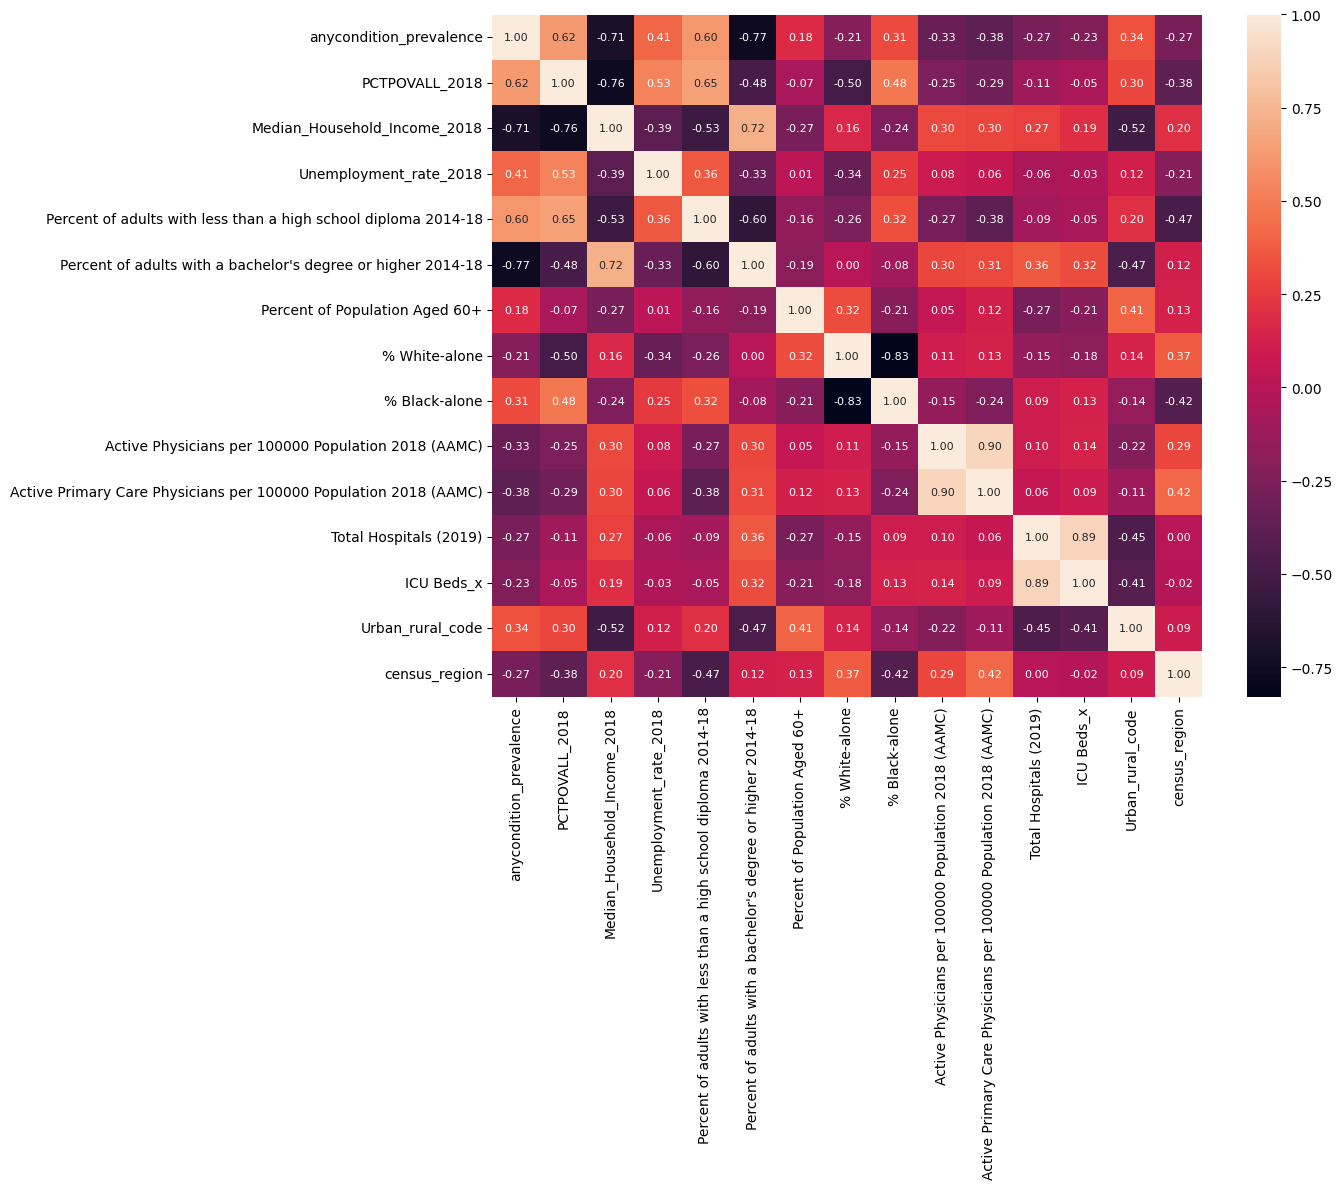

In [85]:
# Factorize the categorical variables / Factorizar las variables categóricas
total_data["COUNTY_NAME"]    = pd.factorize(total_data["COUNTY_NAME"])[0]
total_data["STATE_NAME"]     = pd.factorize(total_data["STATE_NAME"])[0]
total_data["census_region"]  = pd.factorize(total_data["census_region"])[0]

# Select key variables to keep the heatmap readable / Seleccionar variables clave para mantener el mapa de calor legible
key_vars = [
    "anycondition_prevalence",
    "PCTPOVALL_2018", "Median_Household_Income_2018", "Unemployment_rate_2018",
    "Percent of adults with less than a high school diploma 2014-18",
    "Percent of adults with a bachelor's degree or higher 2014-18",
    "Percent of Population Aged 60+",
    "% White-alone", "% Black-alone",
    "Active Physicians per 100000 Population 2018 (AAMC)",
    "Active Primary Care Physicians per 100000 Population 2018 (AAMC)",
    "Total Hospitals (2019)", "ICU Beds_x",
    "Urban_rural_code", "census_region",
]

fig, axes = plt.subplots(figsize = (14, 12))

sns.heatmap(total_data[key_vars].corr(), annot = True, fmt = ".2f", annot_kws = {"size": 8})

plt.tight_layout()

# Draw Plot / Mostrar el gráfico
plt.show()

#### Analysing all the Data at Once

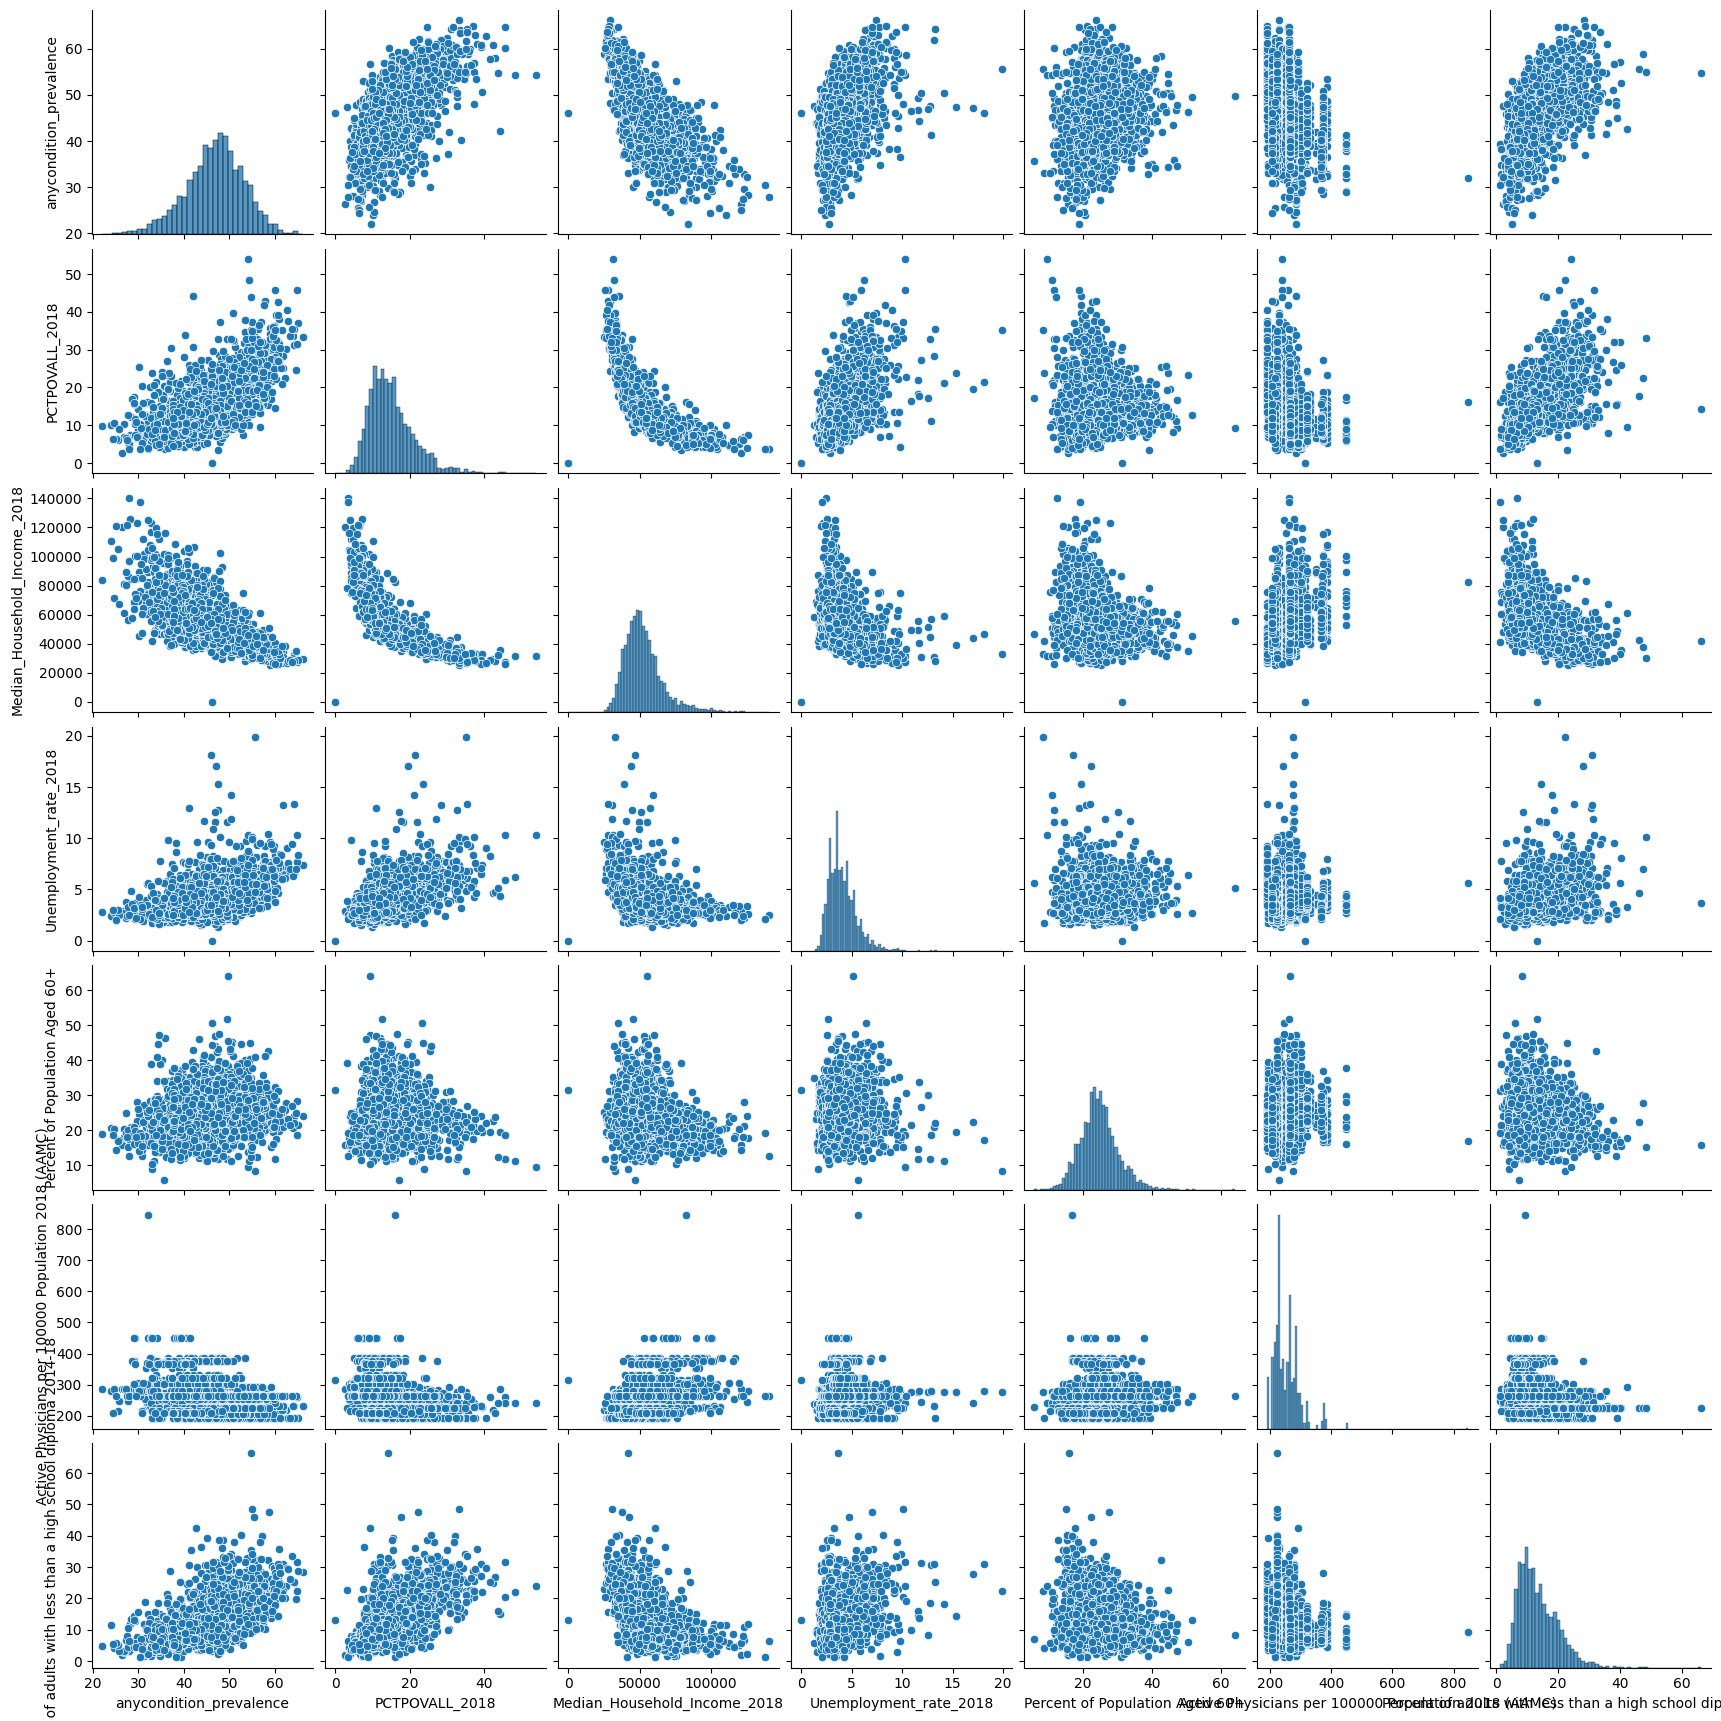

In [86]:
# Pairplot restricted to the most informative variables / Pairplot restringido a las variables más informativas
pairplot_vars = [
    "anycondition_prevalence",
    "PCTPOVALL_2018",
    "Median_Household_Income_2018",
    "Unemployment_rate_2018",
    "Percent of Population Aged 60+",
    "Active Physicians per 100000 Population 2018 (AAMC)",
    "Percent of adults with less than a high school diploma 2014-18",
]

sns.pairplot(data = total_data[pairplot_vars])

Feature engineering / Ingenieria de características

#### Outlier analysis / Analisis de valores atípicos.

In [87]:
total_data.describe()

,TOT_POP,0-9 y/o % of total pop,10-19 y/o % of total pop,20-29 y/o % of total pop,30-39 y/o % of total pop,40-49 y/o % of total pop,50-59 y/o % of total pop,60-69 y/o % of total pop,70-79 y/o % of total pop,80+ y/o % of total pop,...,Internal Medicine Primary Care (2019),Family Medicine/General Practice Primary Care (2019),Total Specialist Physicians (2019),ICU Beds_x,Percent of Population Aged 60+,COUNTY_NAME,STATE_NAME,anycondition_prevalence,Urban_rural_code,census_region
count,3.140000e+03,3140.000000,3140.000000,3140.000000,3140.000000,3140.000000,3140.000000,3140.000000,3140.000000,3140.000000,...,3140.000000,3140.000000,3140.000000,3140.000000,3140.000000,3140.000000,3140.000000,3140.000000,3140.000000,3140.000000
mean,1.041894e+05,11.871051,12.694609,12.283979,11.751535,11.556685,13.526733,13.182225,8.399382,4.733801,...,62.898806,44.393892,167.332629,23.817516,24.736943,688.478981,26.253503,46.793917,4.635350,1.287898
std,3.335834e+05,2.124081,1.815044,3.126297,1.696599,1.372935,1.481692,2.532498,2.214915,1.535028,...,214.737693,133.348667,543.035916,84.602028,5.564871,541.767733,14.260381,6.379448,1.510447,1.335875
min,8.800000e+01,0.000000,0.000000,0.000000,6.092789,2.631579,5.316361,3.444403,2.199551,0.000000,...,0.046773,0.030356,0.111759,0.000000,5.800000,0.000000,0.000000,22.000000,1.000000,-1.000000
25%,1.096325e+04,10.594639,11.674504,10.496774,10.689322,10.685197,12.738561,11.621232,7.032275,3.738648,...,4.843825,5.312558,14.740077,0.000000,21.200000,182.000000,14.000000,42.900000,3.000000,0.000000
50%,2.580050e+04,11.802727,12.687422,11.772649,11.580861,11.618372,13.621339,13.013409,8.208162,4.565338,...,12.386405,12.153987,36.223582,0.000000,24.400000,564.000000,25.000000,47.200000,5.000000,1.000000
75%,6.791300e+04,12.951840,13.659282,13.182260,12.639379,12.386083,14.429115,14.467254,9.445777,5.484143,...,36.902489,31.312501,103.869345,12.000000,27.800000,1129.250000,40.000000,51.000000,6.000000,3.000000
max,1.010552e+07,25.460677,23.304372,37.570198,22.225129,19.430369,20.454545,27.272727,31.327959,22.727273,...,5713.007608,3882.586846,15014.048660,2126.000000,64.200000,1840.000000,50.000000,66.200000,6.000000,3.000000


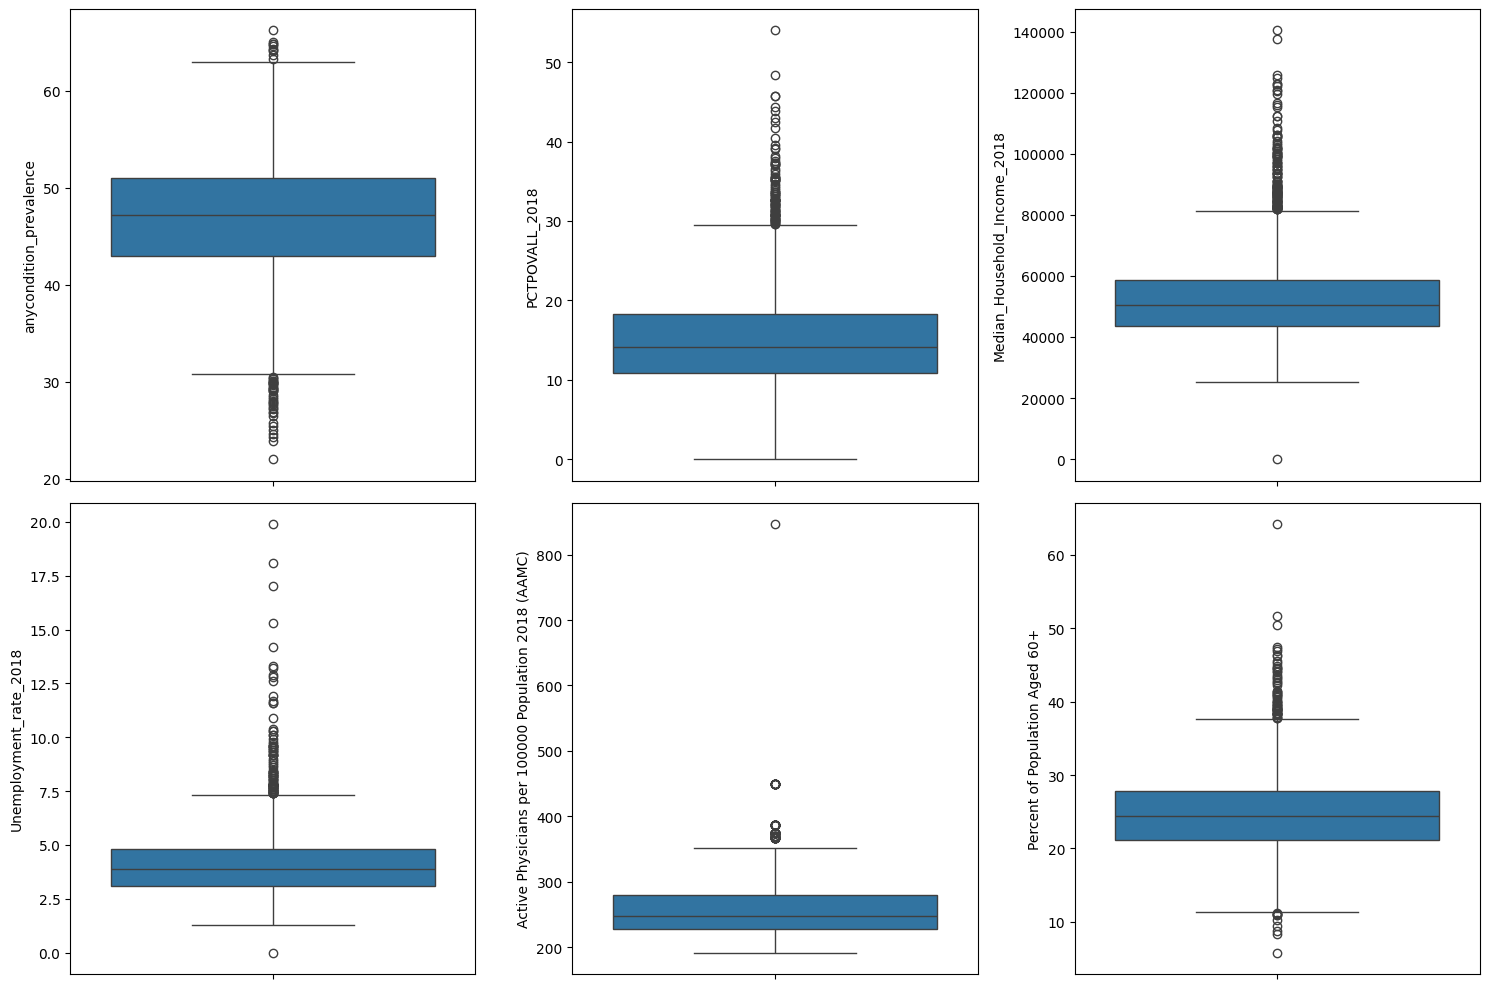

In [88]:
fig, axes = plt.subplots(2, 3, figsize = (15, 10))

sns.boxplot(ax = axes[0, 0], data = total_data, y = "anycondition_prevalence")
sns.boxplot(ax = axes[0, 1], data = total_data, y = "PCTPOVALL_2018")
sns.boxplot(ax = axes[0, 2], data = total_data, y = "Median_Household_Income_2018")
sns.boxplot(ax = axes[1, 0], data = total_data, y = "Unemployment_rate_2018")
sns.boxplot(ax = axes[1, 1], data = total_data, y = "Active Physicians per 100000 Population 2018 (AAMC)")
sns.boxplot(ax = axes[1, 2], data = total_data, y = "Percent of Population Aged 60+")

plt.tight_layout()

plt.show()

##### Outlier detection for `anycondition_prevalence` / Valores atípicos para 'anycondition_prevalence'

In [89]:
# Stats for anycondition_prevalence / Estadísticas para anycondition_prevalence
anycondition_stats = total_data["anycondition_prevalence"].describe()
anycondition_stats

count    3140.000000
mean       46.793917
std         6.379448
min        22.000000
25%        42.900000
50%        47.200000
75%        51.000000
max        66.200000
Name: anycondition_prevalence, dtype: float64

In [90]:
# IQR for anycondition_prevalence / Rango intercuartílico para anycondition_prevalence

anycondition_iqr = anycondition_stats["75%"] - anycondition_stats["25%"]
upper_limit = anycondition_stats["75%"] + 1.5 * anycondition_iqr
lower_limit = anycondition_stats["25%"] - 1.5 * anycondition_iqr

print(f"The upper and lower limits for finding outliers are {round(upper_limit, 2)} and {round(lower_limit, 2)}, with an interquartile range of {round(anycondition_iqr, 2)}")

The upper and lower limits for finding outliers are 63.15 and 30.75, with an interquartile range of 8.1


In [91]:
# Clean the outliers / Limpiar los outliers

total_data = total_data[total_data["anycondition_prevalence"] > 0]

##### Outlier detection for `PCTPOVALL_2018` / Valores atípicos para 'PCTPOVALL_2018'

In [92]:
# Stats for PCTPOVALL_2018 / Estadísticas para PCTPOVALL_2018
pctpov_stats = total_data["PCTPOVALL_2018"].describe()
pctpov_stats

count    3140.000000
mean       15.159459
std         6.131874
min         0.000000
25%        10.800000
50%        14.100000
75%        18.300000
max        54.000000
Name: PCTPOVALL_2018, dtype: float64

In [93]:
# IQR for PCTPOVALL_2018 / Rango intercuartílico para PCTPOVALL_2018

pctpov_iqr = pctpov_stats["75%"] - pctpov_stats["25%"]
upper_limit = pctpov_stats["75%"] + 1.5 * pctpov_iqr
lower_limit = pctpov_stats["25%"] - 1.5 * pctpov_iqr

print(f"The upper and lower limits for finding outliers are {round(upper_limit, 2)} and {round(lower_limit, 2)}, with an interquartile range of {round(pctpov_iqr, 2)}")

The upper and lower limits for finding outliers are 29.55 and -0.45, with an interquartile range of 7.5


In [94]:
# Clean the outliers / Limpiar los outliers

total_data = total_data[total_data["PCTPOVALL_2018"] <= upper_limit]

##### Outlier detection for `Median_Household_Income_2018` / Valores atípicos para 'Median_Household_Income_2018'

In [95]:
# Stats for Median_Household_Income_2018 / Estadísticas para Median_Household_Income_2018

income_stats = total_data["Median_Household_Income_2018"].describe()
income_stats

count      3048.000000
mean      53393.555446
std       13618.973162
min           0.000000
25%       44409.750000
50%       50979.500000
75%       59114.750000
max      140382.000000
Name: Median_Household_Income_2018, dtype: float64

In [96]:
# IQR for Median_Household_Income_2018 / Rango intercuartílico para Median_Household_Income_2018

income_iqr = income_stats["75%"] - income_stats["25%"]
upper_limit = income_stats["75%"] + 1.5 * income_iqr
lower_limit = income_stats["25%"] - 1.5 * income_iqr

print(f"The upper and lower limits for finding outliers are {round(upper_limit, 2)} and {round(lower_limit, 2)}, with an interquartile range of {round(income_iqr, 2)}")

The upper and lower limits for finding outliers are 81172.25 and 22352.25, with an interquartile range of 14705.0


##### Outlier detection for `Unemployment_rate_2018` / Valores atípicos para 'Unemployment_rate_2018'

In [97]:
# Stats for Unemployment_rate_2018 / Estadísticas para Unemployment_rate_2018

unemp_stats = total_data["Unemployment_rate_2018"].describe()
unemp_stats

count    3048.000000
mean        4.052592
std         1.394631
min         0.000000
25%         3.100000
50%         3.800000
75%         4.700000
max        18.100000
Name: Unemployment_rate_2018, dtype: float64

In [98]:
# IQR for Unemployment_rate_2018 / Rango intercuartílico para Unemployment_rate_2018

unemp_iqr = unemp_stats["75%"] - unemp_stats["25%"]
upper_limit = unemp_stats["75%"] + 1.5 * unemp_iqr
lower_limit = unemp_stats["25%"] - 1.5 * unemp_iqr

print(f"The upper and lower limits for finding outliers are {round(upper_limit, 2)} and {round(lower_limit, 2)}, with an interquartile range of {round(unemp_iqr, 2)}")

The upper and lower limits for finding outliers are 7.1 and 0.7, with an interquartile range of 1.6


#### Missing value analysis / Analisis de valores nulos.

In [99]:
# Count NaN values / Contar valores NaN
total_data.isnull().sum().sort_values(ascending = False)

TOT_POP                                                                    0
0-9 y/o % of total pop                                                     0
10-19 y/o % of total pop                                                   0
20-29 y/o % of total pop                                                   0
30-39 y/o % of total pop                                                   0
40-49 y/o % of total pop                                                   0
50-59 y/o % of total pop                                                   0
60-69 y/o % of total pop                                                   0
70-79 y/o % of total pop                                                   0
80+ y/o % of total pop                                                     0
% White-alone                                                              0
% Black-alone                                                              0
% NA/AI-alone                                                              0

#### Feature scaling / Escalamiento de caracteristicas.

In [100]:
from sklearn.preprocessing import MinMaxScaler

num_variables = [col for col in total_data.columns if col != "anycondition_prevalence"]
scaler = MinMaxScaler()
scal_features = scaler.fit_transform(total_data[num_variables])
df_scal = pd.DataFrame(scal_features, index = total_data.index, columns = num_variables)
df_scal["anycondition_prevalence"] = total_data["anycondition_prevalence"]
df_scal.head()

,TOT_POP,0-9 y/o % of total pop,10-19 y/o % of total pop,20-29 y/o % of total pop,30-39 y/o % of total pop,40-49 y/o % of total pop,50-59 y/o % of total pop,60-69 y/o % of total pop,70-79 y/o % of total pop,80+ y/o % of total pop,...,Internal Medicine Primary Care (2019),Family Medicine/General Practice Primary Care (2019),Total Specialist Physicians (2019),ICU Beds_x,Percent of Population Aged 60+,COUNTY_NAME,STATE_NAME,Urban_rural_code,census_region,anycondition_prevalence
0,0.005493,0.513304,0.589390,0.329258,0.412648,0.655099,0.568143,0.295188,0.174554,0.159378,...,0.004542,0.005465,0.004798,0.002822,0.227740,0.000000,0.0,0.4,0.25,47.6
1,0.021566,0.477504,0.529693,0.287860,0.339172,0.589776,0.557352,0.431608,0.254156,0.189060,...,0.017832,0.021453,0.018834,0.023989,0.351027,0.000543,0.0,0.6,0.25,40.2
3,0.002208,0.461062,0.497301,0.359921,0.483782,0.650697,0.567432,0.332260,0.188559,0.154196,...,0.001825,0.002197,0.001928,0.000000,0.261986,0.001630,0.0,0.2,0.25,51.6
4,0.005715,0.515826,0.561604,0.310254,0.360085,0.612560,0.544662,0.360807,0.217166,0.177628,...,0.004725,0.005686,0.004991,0.002822,0.304795,0.002174,0.0,0.2,0.25,46.3
6,0.001939,0.502350,0.536598,0.309177,0.358424,0.544496,0.484943,0.427589,0.214066,0.244370,...,0.001602,0.001929,0.001693,0.003293,0.339041,0.003261,0.0,1.0,0.25,58.1


### Step 6: Feature selection / Seleccion de caracteristicas.

In [101]:
from sklearn.feature_selection import chi2, SelectKBest
from sklearn.model_selection import train_test_split

X = df_scal.drop("anycondition_prevalence", axis = 1)
y = df_scal["anycondition_prevalence"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, random_state = 42
)
# chi2 needs: (1) non-negative X, (2) categorical y
scaler = MinMaxScaler()
X_train_pos = scaler.fit_transform(X_train)
X_test_pos  = scaler.transform(X_test)
y_train_bins = pd.qcut(y_train, q = 5, labels = False, duplicates = "drop")
selection_model = SelectKBest(chi2, k = 10)
selection_model.fit(X_train_pos, y_train_bins)
ix = selection_model.get_support()
X_train_sel = pd.DataFrame(
    selection_model.transform(X_train_pos), columns = X_train.columns.values[ix]
)
X_test_sel = pd.DataFrame(
    selection_model.transform(X_test_pos), columns = X_train.columns.values[ix]
)
X_train_sel.head()

,% Black-alone,% Asian-alone,Percent of adults with less than a high school diploma 2014-18,Percent of adults with a high school diploma only 2014-18,Percent of adults with a bachelor's degree or higher 2014-18,PCTPOVALL_2018,Total physician assistants (2019),Internal Medicine Primary Care (2019),Urban_rural_code,census_region
0,0.373037,0.016625,0.213362,0.497006,0.393631,0.416949,0.001311,0.000933,1.0,0.25
1,0.009353,0.010491,0.114224,0.524950,0.373248,0.349153,0.003317,0.002297,0.8,1.00
2,0.018029,0.012172,0.133621,0.666667,0.248408,0.315254,0.003617,0.001849,0.8,1.00
3,0.009637,0.015979,0.163793,0.473054,0.301911,0.393220,0.000942,0.000510,1.0,1.00
4,0.245641,0.012793,0.293103,0.602794,0.244586,0.440678,0.003859,0.002756,0.4,0.25


#### Save the clean and raw data / Guardar la data cruda y limpia.

In [102]:
X_train_sel["anycondition_prevalence"] = list(y_train)
X_test_sel["anycondition_prevalence"]  = list(y_test)
X_train_sel.to_csv("../data/processed/clean_train.csv", index = False)
X_test_sel.to_csv("../data/processed/clean_test.csv",   index = False)

### Linear Regression / Aplicación de Regresión Lineal.

In [103]:
# Load train and test datasets / Cargar los conjuntos de datos de entrenamiento y prueba
train_data = pd.read_csv("../data/processed/clean_train.csv")
test_data  = pd.read_csv("../data/processed/clean_test.csv")

train_data.head()

,% Black-alone,% Asian-alone,Percent of adults with less than a high school diploma 2014-18,Percent of adults with a high school diploma only 2014-18,Percent of adults with a bachelor's degree or higher 2014-18,PCTPOVALL_2018,Total physician assistants (2019),Internal Medicine Primary Care (2019),Urban_rural_code,census_region,anycondition_prevalence
0,0.373037,0.016625,0.213362,0.497006,0.393631,0.416949,0.001311,0.000933,1.0,0.25,47.6
1,0.009353,0.010491,0.114224,0.524950,0.373248,0.349153,0.003317,0.002297,0.8,1.00,41.7
2,0.018029,0.012172,0.133621,0.666667,0.248408,0.315254,0.003617,0.001849,0.8,1.00,48.1
3,0.009637,0.015979,0.163793,0.473054,0.301911,0.393220,0.000942,0.000510,1.0,1.00,42.2
4,0.245641,0.012793,0.293103,0.602794,0.244586,0.440678,0.003859,0.002756,0.4,0.25,47.2


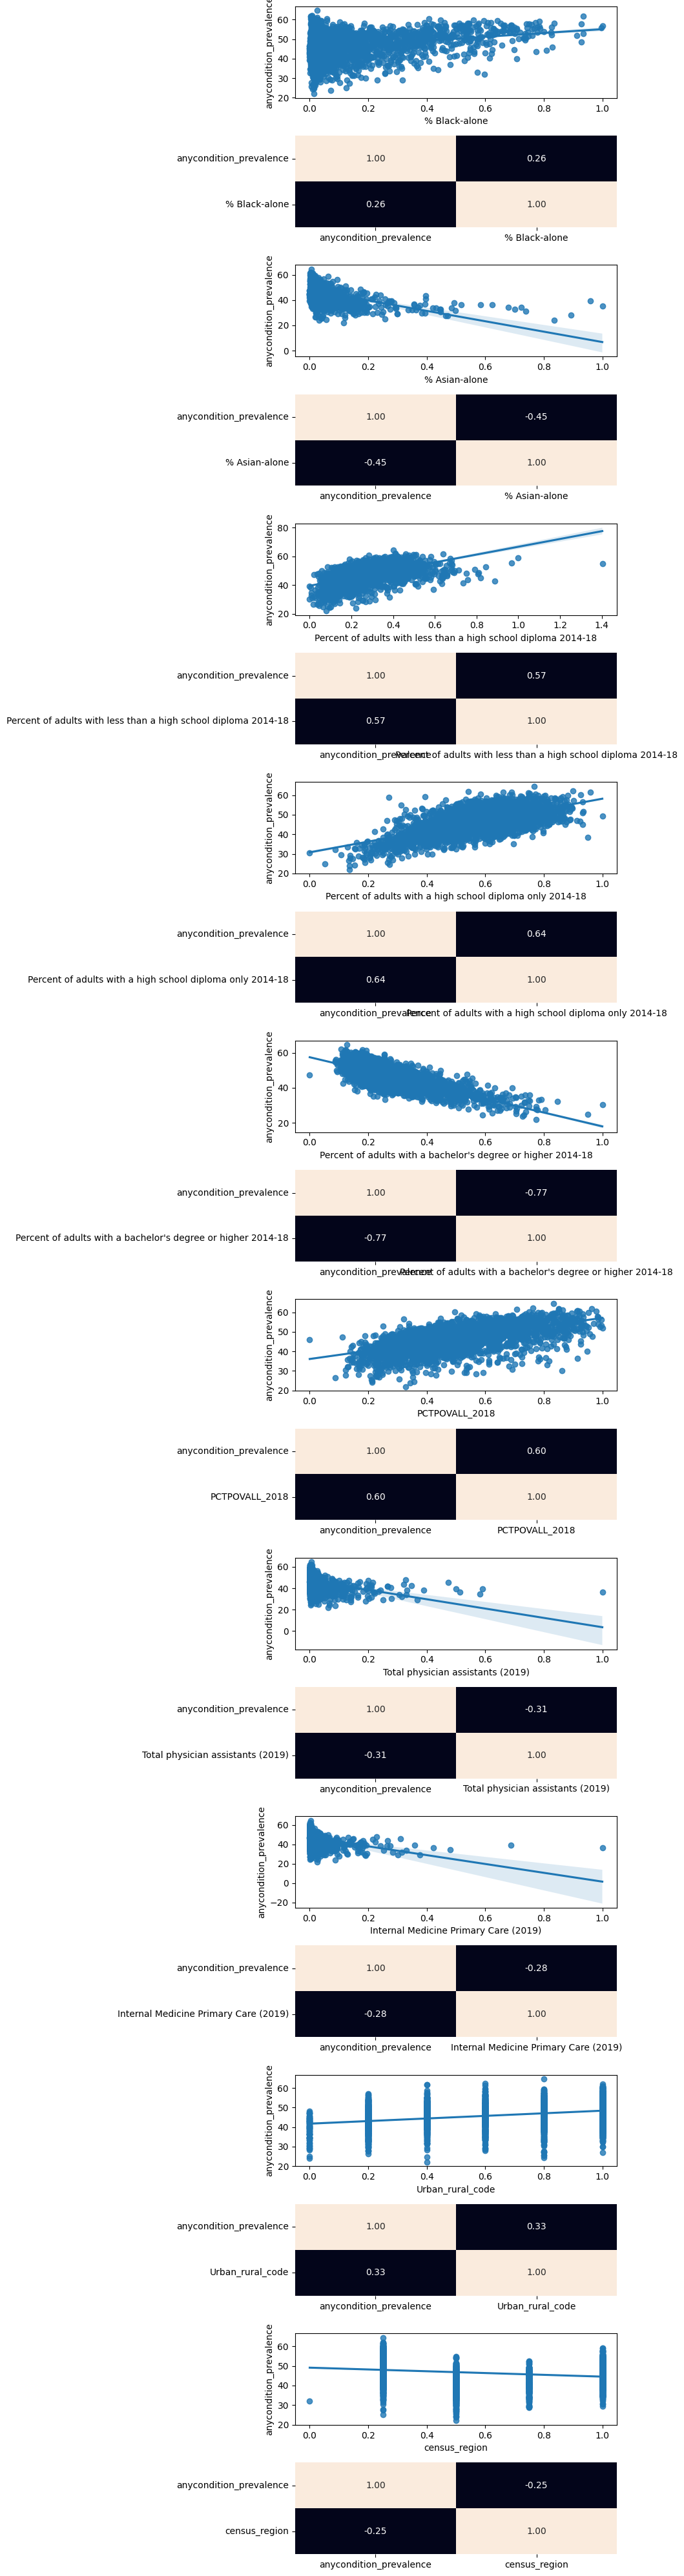

In [104]:
# Visualization of features vs anycondition_prevalence / Visualización de características vs anycondition_prevalence
total_data_lr = pd.concat([train_data, test_data])

selected_features = [col for col in train_data.columns if col != "anycondition_prevalence"]
n = len(selected_features)
fig, axis = plt.subplots(n * 2, 1, figsize = (10, n * 4))

for i, feature in enumerate(selected_features):
    sns.regplot(ax = axis[i * 2],     data = total_data_lr, x = feature, y = "anycondition_prevalence")
    sns.heatmap(total_data_lr[["anycondition_prevalence", feature]].corr(),
                annot = True, fmt = ".2f", ax = axis[i * 2 + 1], cbar = False)

plt.tight_layout()
plt.show()

In [105]:
# Split features and target variable / Separar características y variable objetivo

X_train = train_data.drop(["anycondition_prevalence"], axis = 1)
y_train = train_data["anycondition_prevalence"]
X_test  = test_data.drop(["anycondition_prevalence"], axis = 1)
y_test  = test_data["anycondition_prevalence"]

In [106]:
# Model training / Entrenamiento del modelo
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [107]:
# Model parameters / Parámetros del modelo

print(f"Intercepto (a): {model.intercept_}")
for feature, coef in zip(X_train.columns, model.coef_):
    print(f"Coeficiente {feature}: {coef}")

Intercepto (a): 43.346308009970734
Coeficiente % Black-alone: 4.600488637489078
Coeficiente % Asian-alone: -10.308809424440437
Coeficiente Percent of adults with less than a high school diploma 2014-18: 5.526626373456111
Coeficiente Percent of adults with a high school diploma only 2014-18: 8.758387006602984
Coeficiente Percent of adults with a bachelor's degree or higher 2014-18: -19.801479237624566
Coeficiente PCTPOVALL_2018: 6.255940800008307
Coeficiente Total physician assistants (2019): -18.198524146155645
Coeficiente Internal Medicine Primary Care (2019): 14.292110247624521
Coeficiente Urban_rural_code: -0.5343985561594098
Coeficiente census_region: -0.8295258792380222


In [108]:
# Predictions / Predicciones

y_pred = model.predict(X_test)
y_pred

array([44.48297838, 51.50572054, 46.48984705, 42.52642347, 52.29862366,
       31.47189686, 50.5858636 , 51.73892393, 44.13590576, 43.34227428,
       39.6200294 , 45.16280378, 41.50675459, 51.77733438, 44.7766678 ,
       53.89807091, 40.23455102, 43.76208866, 42.92316222, 47.16660035,
       51.4197224 , 49.85120047, 46.47277944, 49.24506936, 44.33546053,
       53.26340037, 47.50051941, 49.29857148, 48.24798305, 49.39199398,
       44.51267043, 46.84847485, 36.70579382, 49.92829261, 49.44300758,
       42.15230845, 51.15321106, 45.01081104, 46.94350159, 47.0725691 ,
       47.67560959, 45.41691397, 46.37170247, 43.06849734, 44.47853395,
       44.90049938, 48.03146155, 45.1293264 , 57.05364907, 50.20282197,
       51.07002261, 48.4748154 , 49.18580162, 48.77655984, 57.46594602,
       54.78781475, 51.65595968, 49.26569523, 40.76670246, 48.20113412,
       54.92083097, 31.58039225, 46.81825759, 46.38164146, 53.90188147,
       47.14069623, 51.26815385, 48.25195871, 49.16231338, 47.41

In [109]:
# Model evaluation / Evaluación del modelo

print(f"Error cuadrático medio: {mean_squared_error(y_test, y_pred)}")
print(f"Coeficiente de determinación: {r2_score(y_test, y_pred)}")

Error cuadrático medio: 12.155856919767695
Coeficiente de determinación: 0.6852939531042808


# Model validity / Validez del modelo

#### Model validity / Validez del modelo

**Error Cuadrático Medio (MSE):**
Mide el promedio de los errores al cuadrado entre los valores reales y los predichos. No tiene un rango fijo, depende de la escala de la variable objetivo (`anycondition_prevalence`). Un MSE más bajo indica mejor ajuste. Para este dataset, donde `anycondition_prevalence` oscila entre ~20 y ~65, un MSE reducido refleja buena capacidad predictiva; lo importante es compararlo contra modelos alternativos.

**Coeficiente de Determinación (R²):**
Indica qué proporción de la varianza de `anycondition_prevalence` es explicada por el modelo. Sus límites son:
- **R² = 1.0** → ajuste perfecto (el modelo explica toda la varianza).
- **R² = 0.0** → el modelo no explica nada, equivale a predecir siempre la media.
- **R² < 0** → el modelo es peor que predecir la media (señal de sobreajuste o error grave).

Un R² entre **0.7 y 1.0** se considera generalmente un buen modelo para regresión lineal. Si el R² obtenido es bajo (< 0.5), puede indicar que la relación entre las features y `anycondition_prevalence` no es suficientemente lineal, o que se requieren variables adicionales (como `Median_Household_Income_2018` y `PCTPOVALL_2018`, que mostraron alta correlación con el target en el EDA).

Completar con los resultados obtenidos al ejecutar el modelo para evaluar si es necesario someterlo a optimización.

In [110]:
# As R² = 0.6852939531042808, the value is very close to the acceptable between 0.7 & 1.0. Still a trustable model. / 
# Como R² = 0,6852939531042808, el valor está muy cerca del rango aceptable entre 0,7 y 1,0. Sigue siendo un modelo fiable. 

#Due to the number of variables and the potential for overfitting, the next step is to create a regularized linear Lasso model. /
#Debido a la cantidad de variables y al posible sobreajuste, el siguiente paso es crear un modelo lineal regularizado de Lasso.


In [111]:
# CELDA 1
# Lasso import / Importar Lasso
# Lasso adds a penalty to the model proportional to the absolute value of each coefficient (L1 norm).
# This forces irrelevant features to exactly zero, acting as automatic feature selection.
# Lasso añade una penalización proporcional al valor absoluto de cada coeficiente (norma L1).
# Esto fuerza las variables irrelevantes a exactamente cero, actuando como selección automática.
 
from sklearn.linear_model import Lasso
 
# Load train and test datasets / Cargar los conjuntos de datos de entrenamiento y prueba
train_data = pd.read_csv("../data/processed/clean_train.csv")
test_data  = pd.read_csv("../data/processed/clean_test.csv")
 
X_train = train_data.drop(["anycondition_prevalence"], axis = 1)
y_train = train_data["anycondition_prevalence"]
X_test  = test_data.drop(["anycondition_prevalence"], axis = 1)
y_test  = test_data["anycondition_prevalence"]
 

In [112]:
# CELDA 2
# Sweep alpha from 0 to 20 / Barrer alpha de 0 a 20
# alpha=0 behaves like plain Linear Regression (no penalty).
# As alpha grows, more coefficients are forced to zero.
# alpha=0 se comporta como Regresión Lineal pura (sin penalización).
# A medida que alpha crece, más coeficientes son forzados a cero.
 
alphas     = range(0, 21)
r2_scores  = []
mse_scores = []
 
for alpha in alphas:
    if alpha == 0:
        # alpha=0 is plain Linear Regression / alpha=0 es Regresión Lineal pura
        model = LinearRegression()
    else:
        model = Lasso(alpha = alpha, max_iter = 10000)
 
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
 
    r2_scores.append(r2_score(y_test, y_pred))
    mse_scores.append(mean_squared_error(y_test, y_pred))
 
# Collect results / Recopilar resultados
results_df = pd.DataFrame({
    "alpha" : list(alphas),
    "R2"    : r2_scores,
    "MSE"   : mse_scores
})
 
print(results_df.to_string(index = False))
 
 

 alpha        R2       MSE
     0  0.685294 12.155857
     1 -0.000657 38.651426
     2 -0.000657 38.651426
     3 -0.000657 38.651426
     4 -0.000657 38.651426
     5 -0.000657 38.651426
     6 -0.000657 38.651426
     7 -0.000657 38.651426
     8 -0.000657 38.651426
     9 -0.000657 38.651426
    10 -0.000657 38.651426
    11 -0.000657 38.651426
    12 -0.000657 38.651426
    13 -0.000657 38.651426
    14 -0.000657 38.651426
    15 -0.000657 38.651426
    16 -0.000657 38.651426
    17 -0.000657 38.651426
    18 -0.000657 38.651426
    19 -0.000657 38.651426
    20 -0.000657 38.651426


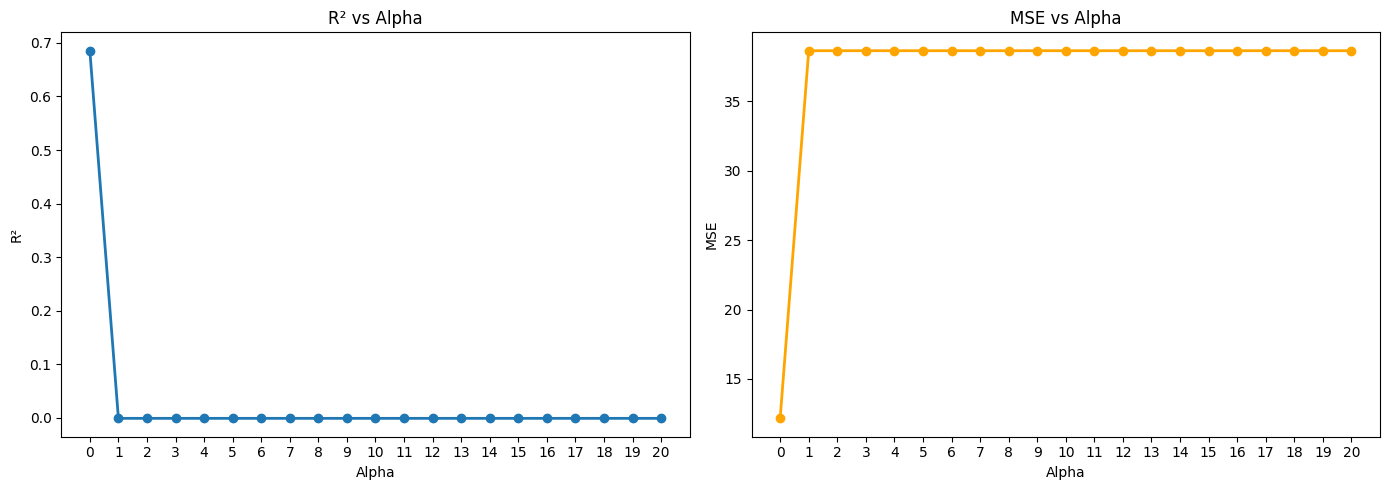

In [113]:
# CELDA 3
# Visualize R² and MSE across alpha values / Visualizar R² y MSE según alpha
 
fig, axis = plt.subplots(1, 2, figsize = (14, 5))
 
axis[0].plot(results_df["alpha"], results_df["R2"], marker = "o", linewidth = 2)
axis[0].set_xlabel("Alpha")
axis[0].set_ylabel("R²")
axis[0].set_title("R² vs Alpha")
axis[0].set_xticks(list(alphas))
 
axis[1].plot(results_df["alpha"], results_df["MSE"], marker = "o", color = "orange", linewidth = 2)
axis[1].set_xlabel("Alpha")
axis[1].set_ylabel("MSE")
axis[1].set_title("MSE vs Alpha")
axis[1].set_xticks(list(alphas))
 
plt.tight_layout()
plt.show()
 

In [114]:
# CELDA 4
# Identify the best alpha / Identificar el mejor alpha
# Best alpha = highest R² (or equivalently, lowest MSE).
# Mejor alpha = mayor R² (o equivalentemente, menor MSE).
 
best_alpha = results_df.loc[results_df["R2"].idxmax(), "alpha"]
best_r2    = results_df.loc[results_df["R2"].idxmax(), "R2"]
best_mse   = results_df.loc[results_df["R2"].idxmax(), "MSE"]
 
print(f"Mejor alpha: {best_alpha}")
print(f"R² con ese alpha: {round(best_r2, 4)}")
print(f"MSE con ese alpha: {round(best_mse, 4)}")
 
 



Mejor alpha: 0
R² con ese alpha: 0.6853
MSE con ese alpha: 12.1559


In [115]:
# ─────────────────────────────────────────────────────────────────────────────
# CELDA 5
# Train final Lasso with the best alpha / Entrenar Lasso final con el mejor alpha
 
lasso_model = Lasso(alpha = best_alpha, max_iter = 10000)
lasso_model.fit(X_train, y_train)
 
print(f"Intercepto (a): {round(lasso_model.intercept_, 4)}")
print()
for feature, coef in zip(X_train.columns, lasso_model.coef_):
    status = "  <- ELIMINADA por Lasso" if coef == 0 else ""
    print(f"  {feature}: {round(coef, 6)}{status}")

/home/vscode/.local/lib/python3.11/site-packages/sklearn/base.py:1336: UserWarning: With alpha=0, this algorithm does not converge well. You are advised to use the LinearRegression estimator
  return fit_method(estimator, *args, **kwargs)
/home/vscode/.local/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:716: UserWarning: Coordinate descent with no regularization may lead to unexpected results and is discouraged.
  model = cd_fast.enet_coordinate_descent(


Intercepto (a): 43.3463

  % Black-alone: 4.600489
  % Asian-alone: -10.308809
  Percent of adults with less than a high school diploma 2014-18: 5.526626
  Percent of adults with a high school diploma only 2014-18: 8.758387
  Percent of adults with a bachelor's degree or higher 2014-18: -19.801479
  PCTPOVALL_2018: 6.255941
  Total physician assistants (2019): -18.198524
  Internal Medicine Primary Care (2019): 14.29211
  Urban_rural_code: -0.534399
  census_region: -0.829526


/home/vscode/.local/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.383e+04, tolerance: 9.232e+00
Linear regression models with a zero l1 penalization strength are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_coordinate_descent(


In [116]:
# CELDA 6
# Predictions and evaluation / Predicciones y evaluación
 
y_pred_lasso = lasso_model.predict(X_test)
 
print(f"Error cuadrático medio (Lasso): {mean_squared_error(y_test, y_pred_lasso)}")
print(f"Coeficiente de determinación (Lasso): {r2_score(y_test, y_pred_lasso)}")
 
 

Error cuadrático medio (Lasso): 12.155856919767695
Coeficiente de determinación (Lasso): 0.6852939531042808


In [117]:
# CELDA 7
# Compare Linear Regression vs Lasso / Comparar Regresión Lineal vs Lasso
# A good Lasso model should have a similar or better R² than Linear Regression,
# while using fewer variables — simpler and more generalizable.
# Un buen modelo Lasso debe tener un R² similar o mejor que la Regresión Lineal,
# usando menos variables — más simple y generalizable.
 
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)
y_pred_linear = linear_model.predict(X_test)
 
mse_linear = mean_squared_error(y_test, y_pred_linear)
r2_linear  = r2_score(y_test, y_pred_linear)
 
n_features_linear = X_train.shape[1]
n_features_lasso  = np.sum(lasso_model.coef_ != 0)
 
print("-" * 52)
print(f"{'Modelo':<25} {'MSE':>10} {'R2':>8} {'Variables':>10}")
print("-" * 52)
print(f"{'Regresion Lineal':<25} {round(mse_linear, 4):>10} {round(r2_linear, 4):>8} {n_features_linear:>10}")
print(f"{'Lasso':<25} {round(mean_squared_error(y_test, y_pred_lasso), 4):>10} {round(r2_score(y_test, y_pred_lasso), 4):>8} {n_features_lasso:>10}")
print("-" * 52)

----------------------------------------------------
Modelo                           MSE       R2  Variables
----------------------------------------------------
Regresion Lineal             12.1559   0.6853         10
Lasso                        12.1559   0.6853         10
----------------------------------------------------
